# Differentiable Glass-Selection & Model-Glass Tolerancing

This notebook is the second step of the thesis arc.

- `model_glass_buchdahl.ipynb` built and validated the 3-parameter
  Buchdahl dispersion model $(n_d, V_d, \Delta P_{g,F}) \to n(\lambda)$.
- `glass_substitution_workflow.ipynb` used it as a **decision tool**
  — validating it across 5 concrete claims (accuracy, physical meaning,
  design-practice consensus, catalog gap, $(n_d, V_d)$ tolerancing
  smoothness).

Here we take the next step: **make the whole glass-selection pipeline
fully differentiable**. Every quantity a designer cares about (EFL,
axial color, secondary spectrum $S$, yield) becomes a function whose
gradient w.r.t. glass parameters and surface curvatures can be obtained
by calling `.backward()`.

**Why this is not just a speed trick.**

- Gradient-based optimization (Adam / LBFGS) scales to many DOF without
  wrapping every objective evaluation in a nested `fsolve` loop.
- Analytical Jacobians turn Monte Carlo tolerancing into **linear
  covariance propagation** — exact and cheap.
- Yield-aware loss functions become well-defined objectives for
  gradient descent.

**Arc.**
| Part | Content |
|---|---|
| 1 | Switch Optiland to `torch` backend; make `BuchdahlModelGlass` autograd-compatible. |
| 2 | Complement the workflow notebook's Claim E heatmap with a **fixed-prescription local Jacobian** obtained in one backward pass (different question from the heatmap: "what if the lens is already built and the glass drifts" vs. "what if each sample is freshly achromatized"). |
| 3 | Adam warm-up + LBFGS polish jointly optimize glass + curvatures to apo conditions. |
| 4 | Scale up to a 15-DOF paraxial triplet toy as an end-to-end differentiability test. |
| 5 | Analytical model-glass tolerancing: propagate manufacturing covariance via the Jacobian. Compare to Monte Carlo. |


## Part 1 — torch backend + autograd-ready BuchdahlModelGlass


In [1]:
from __future__ import annotations
import os
# Intel OMP and torch OMP both ship with libiomp5md on Windows; Python
# must load one before the other. Setting this flag BEFORE importing
# torch is the standard workaround. Without it the kernel segfaults
# when matplotlib and torch interact.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import time  # noqa: E402

import numpy as np  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402

import torch  # noqa: E402

import optiland.backend as be  # noqa: E402
be.set_backend("torch")        # <-- the single line that turns it all differentiable
print("Optiland backend:", be.get_backend())

from optiland import optic  # noqa: E402
from optiland.materials.base import BaseMaterial  # noqa: E402

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)


Optiland backend: torch


In [2]:
# ---- Spectral-line constants and Buchdahl alpha (identical to the other
#      two notebooks so the model is byte-identical).

LAMBDA_D = 0.5875618
LAMBDA_g = 0.4358343
LAMBDA_F = 0.4861327
LAMBDA_C = 0.6562725
ALPHA    = 1.818   # optimized alpha from model_glass_buchdahl.ipynb


def buchdahl_omega(lam, alpha=ALPHA):
    dl = lam - LAMBDA_D
    return dl / (1.0 + alpha * dl)


OMEGA_g = buchdahl_omega(LAMBDA_g)
OMEGA_F = buchdahl_omega(LAMBDA_F)
OMEGA_C = buchdahl_omega(LAMBDA_C)


# Load the pre-trained nu3, nu4 regression matrix (20x2) — same file the
# workflow notebook uses.
A_REG_np = np.load("regression_buchdahl_nu34_20dim_opt.npy")
A_REG = torch.tensor(A_REG_np, dtype=torch.float64)
print(f"Loaded A_reg: shape = {tuple(A_REG.shape)}  (alpha = {ALPHA})")


Loaded A_reg: shape = (20, 2)  (alpha = 1.818)


In [3]:
# ---- Torch-friendly rewrite of the Buchdahl predictor ----
#
# Critical: nothing in this function converts to numpy. Every op goes
# through torch, so autograd flows through nd, vd, dPgF.

def _to_scalar_tensor(x):
    if isinstance(x, torch.Tensor):
        return x.to(dtype=torch.float64)
    return torch.tensor(float(x), dtype=torch.float64)


def analytical_nu12_torch(nd, vd, dPgF):
    dn_FC = (nd - 1.0) / vd
    PgF   = 0.6438 - 0.001682 * vd + dPgF
    dn_gF = PgF * dn_FC
    # 2x2 system
    M = torch.tensor([
        [OMEGA_F - OMEGA_C,   OMEGA_F**2 - OMEGA_C**2],
        [OMEGA_g - OMEGA_F,   OMEGA_g**2 - OMEGA_F**2],
    ], dtype=torch.float64)
    rhs = torch.stack([dn_FC, dn_gF])
    return torch.linalg.solve(M, rhs)


def feature_vec_torch(nd, vd, dPgF):
    one = torch.ones((), dtype=torch.float64)
    return torch.stack([
        one, nd, vd, dPgF,
        nd*nd, vd*vd, dPgF*dPgF,
        nd*vd, nd*dPgF, vd*dPgF,
        nd*nd*nd, vd*vd*vd, dPgF*dPgF*dPgF,
        nd*nd*vd, nd*nd*dPgF,
        vd*vd*nd, vd*vd*dPgF,
        dPgF*dPgF*nd, dPgF*dPgF*vd,
        nd*vd*dPgF,
    ])


def predict_index_torch(nd, vd, dPgF, lam):
    """n(lambda) via the 3-parameter Buchdahl model, autograd-friendly.

    nd, vd, dPgF: scalar torch tensors (may have requires_grad=True).
    lam: torch tensor (any shape).
    Returns: n(lambda) tensor with the same shape as lam.
    """
    nd   = _to_scalar_tensor(nd)
    vd   = _to_scalar_tensor(vd)
    dPgF = _to_scalar_tensor(dPgF)
    if not isinstance(lam, torch.Tensor):
        lam = torch.tensor(lam, dtype=torch.float64)
    else:
        lam = lam.to(dtype=torch.float64)

    nu12 = analytical_nu12_torch(nd, vd, dPgF)              # [2]
    phi  = feature_vec_torch(nd, vd, dPgF)                  # [20]
    nu34 = phi @ A_REG                                      # [2]
    omega = (lam - LAMBDA_D) / (1.0 + ALPHA * (lam - LAMBDA_D))

    n = nd * torch.ones_like(lam)
    for k, nu_k in enumerate(
        (nu12[0], nu12[1], nu34[0], nu34[1]), start=1
    ):
        n = n + nu_k * omega**k
    return n


In [4]:
# ---- Autograd smoke test on N-BK7 ----
nd_bk7   = torch.tensor(1.5168, dtype=torch.float64, requires_grad=True)
vd_bk7   = torch.tensor(64.17,  dtype=torch.float64, requires_grad=True)
dPgF_bk7 = torch.tensor(0.0034, dtype=torch.float64, requires_grad=True)

# Predict at F, d, C
lam = torch.tensor([LAMBDA_F, LAMBDA_D, LAMBDA_C], dtype=torch.float64)
n_pred = predict_index_torch(nd_bk7, vd_bk7, dPgF_bk7, lam)
print("n(F, d, C) =", n_pred.detach().numpy())

# Check analytical gradient: dn(F)/d(nd) should be close to 1 (nd appears
# as the constant term in the expansion and dominates for small omega).
n_F = n_pred[0]
n_F.backward()


def _g(t: torch.Tensor) -> torch.Tensor:
    # .grad is Optional[Tensor] until .backward() populates it; helper
    # unwraps it so downstream .item()/.numpy() calls type-check.
    assert t.grad is not None, "call .backward() before reading .grad"
    return t.grad


print(f"  dn(F)/dnd   = {_g(nd_bk7).item():+.4f}  (expected ~1)")
print(f"  dn(F)/dvd   = {_g(vd_bk7).item():+.4e}")
print(f"  dn(F)/dPgF  = {_g(dPgF_bk7).item():+.4e}")


n(F, d, C) = [1.52249196 1.5168     1.51434278]
  dn(F)/dnd   = +1.0108  (expected ~1)
  dn(F)/dvd   = -9.1167e-05
  dn(F)/dPgF  = +7.6682e-06


In [5]:
# ---- Torch-differentiable BuchdahlModelGlass ----
#
# Plugs into Optiland's material system; keeps the glass-parameter
# tensors as attributes so autograd can reach them from anywhere in the
# optical pipeline.

class BuchdahlTorch(BaseMaterial):
    def __init__(self, nd, vd, dPgF, label=""):
        super().__init__()
        self.nd   = _to_scalar_tensor(nd)
        self.vd   = _to_scalar_tensor(vd)
        self.dPgF = _to_scalar_tensor(dPgF)
        self.label = label

    def _calculate_n(self, wavelength, **kwargs):
        lam = wavelength
        if not isinstance(lam, torch.Tensor):
            lam = torch.tensor(float(lam), dtype=torch.float64)
        else:
            lam = lam.to(dtype=torch.float64)
        n = predict_index_torch(self.nd, self.vd, self.dPgF, lam)
        # Optiland expects the output to broadcast; keep original shape.
        return n.reshape(lam.shape) if lam.ndim > 0 else n.reshape(())

    def _calculate_k(self, wavelength, **kwargs):
        if not isinstance(wavelength, torch.Tensor):
            wavelength = torch.tensor(float(wavelength), dtype=torch.float64)
        return torch.zeros_like(wavelength, dtype=torch.float64)

    def to_dict(self):
        d = super().to_dict()
        d.update({
            "nd":   float(self.nd.detach().item()),
            "vd":   float(self.vd.detach().item()),
            "dPgF": float(self.dPgF.detach().item()),
            "label": self.label,
        })
        return d


# Smoke test: build a singlet with one tensor-backed material, verify
# that dBFL/dnd can be computed by autograd.
nd_var = torch.tensor(1.5, dtype=torch.float64, requires_grad=True)
mat = BuchdahlTorch(nd_var, torch.tensor(60.0, dtype=torch.float64),
                    torch.tensor(0.0, dtype=torch.float64), label="test")

lens = optic.Optic()
s = lens.surfaces
s.add(index=0, radius=be.inf, thickness=be.inf)
s.add(index=1, radius=10.0, thickness=1.0, is_stop=True, material=mat)
s.add(index=2, radius=-10.0, thickness=10.0)
s.add(index=3)
lens.set_aperture(aperture_type="imageFNO", value=6.0)
lens.fields.set_type(field_type="angle")
lens.fields.add(y=0)
lens.wavelengths.add(value=LAMBDA_D, is_primary=True)

epd_raw = lens.paraxial.EPD()
epd_val = epd_raw.detach() if isinstance(epd_raw, torch.Tensor) else epd_raw
ya, ua = lens.paraxial.trace_generic(
    y=float(epd_val)/2.0,
    u=0.0, z=0.0, wavelength=LAMBDA_D, skip=1,
)
bfl = -ya[-2] / ua[-2]
print(f"BFL           = {bfl.item():.5f} mm")
bfl.sum().backward()
print(f"d(BFL)/d(nd)  = {_g(nd_var).item():+.3f}  "
      f"(analytic biconvex thin-lens: ~ -20)")


BFL           = 9.83051 mm
d(BFL)/d(nd)  = -19.891  (analytic biconvex thin-lens: ~ -20)


## Part 2 — analytical gradients (via autograd)

The workflow notebook's Claim E heatmap estimated sensitivities by
a 21×21 grid in which **each cell re-designs the achromat**. Here we
take a different, complementary question: **short-term sensitivity at
fixed curvatures** — what happens if the lens is already built and the
glass parameters drift. That is the quantity relevant to incoming-glass
QA, and it's the one the Jacobian naturally computes in a single
backward pass.

(The two sensitivities differ: with fresh achromatization per sample
some of the perturbation is absorbed into the re-solved $r_1, r_3$;
at fixed curvatures all of it shows up in $S$.)


In [6]:
# Winner glass from the workflow notebook (D-FK95-25) in torch form.
# Glass parameters recomputed via Sellmeier + Schott normal line — the
# same values the workflow notebook uses after its catalog-loader refactor
# (NOT the stored SPECS values, which use per-catalog normal lines and
# disagree by O(1e-3) on dPgF).
WINNER = dict(nd=1.4374, vd=94.44, dPgF=+0.0485)   # D-FK95-25 (CDGM winner)
FLINT  = dict(nd=1.6477, vd=33.82, dPgF=+0.0081)   # N-SF2
TARGET_EFL = 20.0
TARGET_FNO = 6.0
R2_FIXED   = -7.94140
T1, T2     = 0.434, 0.321


from scipy.optimize import fsolve  # noqa: E402


def design_achromat_solve(nd_c, vd_c, dPgF_c, nd_f, vd_f, dPgF_f,
                          target_efl=TARGET_EFL, r2=R2_FIXED,
                          t1=T1, t2=T2,
                          r1_init=12.38401, r3_init=-48.44396):
    """Solve (r1, r3) for the primary achromat via numpy fsolve (fast,
    robust). Returns (r1, r3) as plain floats — detached from autograd,
    which is exactly what we want: autograd on glass parameters still
    flows through `secondary_spectrum_torch(r1, r3, nd, vd, dPgF, ...)`
    when we evaluate the metric with these radii as fixed constants.
    """
    # Detach to plain floats so scipy can use them
    _nd_c = float(nd_c.detach() if isinstance(nd_c, torch.Tensor) else nd_c)
    _vd_c = float(vd_c.detach() if isinstance(vd_c, torch.Tensor) else vd_c)
    _dP_c = float(dPgF_c.detach() if isinstance(dPgF_c, torch.Tensor) else dPgF_c)
    _nd_f = float(nd_f.detach() if isinstance(nd_f, torch.Tensor) else nd_f)
    _vd_f = float(vd_f.detach() if isinstance(vd_f, torch.Tensor) else vd_f)
    _dP_f = float(dPgF_f.detach() if isinstance(dPgF_f, torch.Tensor) else dPgF_f)

    lams_np = np.array([LAMBDA_F, LAMBDA_D, LAMBDA_C])
    with torch.no_grad():
        n_c_t = predict_index_torch(
            torch.tensor(_nd_c), torch.tensor(_vd_c), torch.tensor(_dP_c),
            torch.tensor(lams_np))
        n_f_t = predict_index_torch(
            torch.tensor(_nd_f), torch.tensor(_vd_f), torch.tensor(_dP_f),
            torch.tensor(lams_np))
    n_c = n_c_t.numpy()
    n_f = n_f_t.numpy()

    def paraxial_np(r1, r2, r3, t1, t2, ncr, nfl):
        y = 1.0
        u = 0.0
        u = (u - (ncr - 1.0)*y/r1) / ncr
        y = y + u*t1
        u = (ncr*u - (nfl - ncr)*y/r2) / nfl
        y = y + u*t2
        u = nfl*u - (1.0 - nfl)*y/r3
        return -1.0/u, -y/u

    def residuals(r13):
        r1, r3 = r13
        efl_d, _ = paraxial_np(r1, r2, r3, t1, t2, n_c[1], n_f[1])
        _, bfl_F = paraxial_np(r1, r2, r3, t1, t2, n_c[0], n_f[0])
        _, bfl_C = paraxial_np(r1, r2, r3, t1, t2, n_c[2], n_f[2])
        return [efl_d - target_efl, bfl_F - bfl_C]

    sol, info, ier, msg = fsolve(residuals, x0=[r1_init, r3_init],
                                 full_output=True, xtol=1e-10)
    if ier != 1:
        raise RuntimeError(f"fsolve failed: {msg}")
    return float(sol[0]), float(sol[1])


def paraxial_trace_torch(r1, r2, r3, t1, t2, n_c, n_f):
    """Same math as the numpy version in the workflow notebook."""
    y = torch.tensor(1.0, dtype=torch.float64)
    u = torch.tensor(0.0, dtype=torch.float64)
    u = (u - (n_c - 1.0) * y / r1) / n_c
    y = y + u * t1
    u = (n_c * u - (n_f - n_c) * y / r2) / n_f
    y = y + u * t2
    u = n_f * u - (1.0 - n_f) * y / r3
    return -1.0 / u, -y / u


def secondary_spectrum_torch(r1, r3, nd_c, vd_c, dPgF_c,
                             nd_f, vd_f, dPgF_f,
                             r2=R2_FIXED, t1=T1, t2=T2):
    lams = torch.tensor([LAMBDA_g, LAMBDA_D], dtype=torch.float64)
    n_c = predict_index_torch(nd_c, vd_c, dPgF_c, lams)
    n_f = predict_index_torch(nd_f, vd_f, dPgF_f, lams)
    _, bfl_g = paraxial_trace_torch(r1, r2, r3, t1, t2, n_c[0], n_f[0])
    _, bfl_d = paraxial_trace_torch(r1, r2, r3, t1, t2, n_c[1], n_f[1])
    return torch.abs(bfl_g - bfl_d)


In [7]:
# Evaluate gradients at the WINNER nominal
nd_c = torch.tensor(WINNER["nd"],   dtype=torch.float64, requires_grad=True)
vd_c = torch.tensor(WINNER["vd"],   dtype=torch.float64, requires_grad=True)
dP_c = torch.tensor(WINNER["dPgF"], dtype=torch.float64, requires_grad=True)

# Solve (r1, r3) via numpy fsolve (detached). Treat them as constants
# here; the question is the sensitivity of S to glass parameters at
# fixed, achromatized radii — the fixed-prescription complement to
# Claim E's re-designed heatmap in the workflow notebook.
r1_val, r3_val = design_achromat_solve(
    nd_c, vd_c, dP_c,
    FLINT["nd"], FLINT["vd"], FLINT["dPgF"],
)
r1_t = torch.tensor(r1_val, dtype=torch.float64)
r3_t = torch.tensor(r3_val, dtype=torch.float64)

S = secondary_spectrum_torch(
    r1_t, r3_t, nd_c, vd_c, dP_c,
    torch.tensor(FLINT["nd"]),
    torch.tensor(FLINT["vd"]),
    torch.tensor(FLINT["dPgF"]),
)
print(f"S (nominal)            = {S.item()*1e3:.3f} um")
S.backward()
g_nd = _g(nd_c).item()
g_vd = _g(vd_c).item()
g_dP = _g(dP_c).item()
print(f"dS/d(nd_crown)  (fixed radii) = {g_nd*1e3:+8.2f}  um / unit nd")
print(f"dS/d(Vd_crown)  (fixed radii) = {g_vd*1e3:+8.4f} um / unit Vd")
print(f"dS/d(dPgF_crown)              = {g_dP*1e3:+8.2f}  um / unit dPgF")
print()
print("Schott 'Step 1.0' grade tolerances (typical crown glass):")
print("  sigma_nd   ~ 5e-4   -> 1-sigma dS contribution = "
      f"{abs(g_nd*1e3) * 5e-4:.3f} um")
print("  sigma_Vd   ~ 0.3    -> 1-sigma dS contribution = "
      f"{abs(g_vd*1e3) * 0.3:.3f} um")
print("  sigma_dPgF ~ 3e-4   -> 1-sigma dS contribution = "
      f"{abs(g_dP*1e3) * 3e-4:.3f} um")


S (nominal)            = 29.789 um
dS/d(nd_crown)  (fixed radii) =  -958.41  um / unit nd
dS/d(Vd_crown)  (fixed radii) =  +5.0970 um / unit Vd
dS/d(dPgF_crown)              =  +282.45  um / unit dPgF

Schott 'Step 1.0' grade tolerances (typical crown glass):
  sigma_nd   ~ 5e-4   -> 1-sigma dS contribution = 0.479 um
  sigma_Vd   ~ 0.3    -> 1-sigma dS contribution = 1.529 um
  sigma_dPgF ~ 3e-4   -> 1-sigma dS contribution = 0.085 um


## Part 3 — gradient-based joint design of the apo doublet

Joint optimization over the 3-parameter crown glass and the two free
surface curvatures. The loss combines the three physical conditions
in **scale-normalized** form so each term has comparable weight:

$$\mathcal{L}
 = \left(\frac{S}{s_S}\right)^2
 + \left(\frac{\text{EFL} - \text{target}}{s_\text{EFL}}\right)^2
 + \left(\frac{\text{AxColor}}{s_\text{AxC}}\right)^2$$

Two engineering details matter:

- **Curvatures $c_1 = 1/r_1$ and $c_3 = 1/r_3$** as training variables,
  not radii. Power is linear in $c$ and smooth near plano ($r \to
  \infty$), so gradient descent behaves much better.
- **Adam warm-up → LBFGS polish**. Adam finds the right basin fast;
  LBFGS converges to machine precision inside it.

We also run the optimization from **two different initializations**
to show that the achromat condition + EFL constraint has a *solution
manifold* (not a unique point): one starting from N-LAK14 (high-index
crown), one starting from a mid-index crown. Both should reach
primary achromatization and drive $S$ to numerical zero, landing at
**different** $(n_d, V_d, r_1, r_3)$ — different points on the
same 2-D constraint surface.


In [8]:
NLAK14 = dict(nd=1.6968, vd=55.41, dPgF=-0.0079)   # recomputed from Sellmeier

# Fixed flint as torch constants (not trainable here)
nd_f = torch.tensor(FLINT["nd"],   dtype=torch.float64)
vd_f = torch.tensor(FLINT["vd"],   dtype=torch.float64)
dP_f = torch.tensor(FLINT["dPgF"], dtype=torch.float64)

BOUNDS = dict(nd_c=(1.44, 2.00), vd_c=(20.0, 95.0), dP_c=(-0.015, 0.055))


def clamp_(p, lo, hi):
    with torch.no_grad():
        p.clamp_(lo, hi)


def doublet_metrics_c(nd_c, vd_c, dP_c, c1, c3,
                      nd_f, vd_f, dP_f,
                      r2=R2_FIXED, t1=T1, t2=T2):
    """(EFL, AxColor, S) using curvatures c1=1/r1, c3=1/r3."""
    r1 = 1.0 / c1
    r3 = 1.0 / c3
    lams = torch.tensor([LAMBDA_F, LAMBDA_D, LAMBDA_C, LAMBDA_g],
                        dtype=torch.float64)
    n_c = predict_index_torch(nd_c, vd_c, dP_c, lams)
    n_f_ = predict_index_torch(nd_f, vd_f, dP_f, lams)
    efl_d, bfl_d = paraxial_trace_torch(r1, r2, r3, t1, t2, n_c[1], n_f_[1])
    _,     bfl_F = paraxial_trace_torch(r1, r2, r3, t1, t2, n_c[0], n_f_[0])
    _,     bfl_C = paraxial_trace_torch(r1, r2, r3, t1, t2, n_c[2], n_f_[2])
    _,     bfl_g = paraxial_trace_torch(r1, r2, r3, t1, t2, n_c[3], n_f_[3])
    return efl_d, bfl_F - bfl_C, torch.abs(bfl_g - bfl_d)


# Loss-scale normalization: so each of the three constraints contributes
# at comparable magnitude to the loss gradient.
S_SCALE, EFL_SCALE, AX_SCALE = 0.010, 1.0, 0.010   # mm

def normalized_loss(nd_c, vd_c, dP_c, c1, c3):
    efl, ax, S = doublet_metrics_c(nd_c, vd_c, dP_c, c1, c3,
                                   nd_f, vd_f, dP_f)
    return ((S/S_SCALE)**2 +
            ((efl - TARGET_EFL)/EFL_SCALE)**2 +
            (ax/AX_SCALE)**2), efl, ax, S


def run_from_init(init, adam_steps=200, lbfgs_iters=30, lr_adam=5e-3):
    p = {
        "nd_c": torch.tensor(init["nd"],   dtype=torch.float64, requires_grad=True),
        "vd_c": torch.tensor(init["vd"],   dtype=torch.float64, requires_grad=True),
        "dP_c": torch.tensor(init["dPgF"], dtype=torch.float64, requires_grad=True),
        "c1":   torch.tensor(1.0/init["r1"], dtype=torch.float64, requires_grad=True),
        "c3":   torch.tensor(1.0/init["r3"], dtype=torch.float64, requires_grad=True),
    }
    history = []

    # --- Adam warm-up ---
    adam = torch.optim.Adam(list(p.values()), lr=lr_adam)
    for step in range(adam_steps):
        adam.zero_grad()
        loss, efl, ax, S = normalized_loss(p["nd_c"], p["vd_c"], p["dP_c"], p["c1"], p["c3"])
        loss.backward()
        adam.step()
        clamp_(p["nd_c"], *BOUNDS["nd_c"])
        clamp_(p["vd_c"], *BOUNDS["vd_c"])
        clamp_(p["dP_c"], *BOUNDS["dP_c"])
        history.append((S.item()*1e3, efl.item(), ax.item()*1e3))

    # --- LBFGS polish ---
    lbfgs = torch.optim.LBFGS(list(p.values()), lr=0.1, max_iter=20,
                              line_search_fn="strong_wolfe",
                              tolerance_grad=1e-12, tolerance_change=1e-16)
    def closure():
        lbfgs.zero_grad()
        loss, _, _, _ = normalized_loss(p["nd_c"], p["vd_c"], p["dP_c"], p["c1"], p["c3"])
        loss.backward()
        return loss

    for _ in range(lbfgs_iters):
        lbfgs.step(closure)
        clamp_(p["nd_c"], *BOUNDS["nd_c"])
        clamp_(p["vd_c"], *BOUNDS["vd_c"])
        clamp_(p["dP_c"], *BOUNDS["dP_c"])
        _, efl, ax, S = normalized_loss(p["nd_c"], p["vd_c"], p["dP_c"], p["c1"], p["c3"])
        history.append((S.item()*1e3, efl.item(), ax.item()*1e3))

    # Final eval — guarantees efl/ax/S are set even if loop counts are 0.
    _, efl, ax, S = normalized_loss(p["nd_c"], p["vd_c"], p["dP_c"], p["c1"], p["c3"])
    return p, (efl, ax, S), history


# Two different starting regimes — both are valid points on the
# 2-D constraint manifold, and they converge to different solutions.
INIT_HIGH_INDEX = dict(nd=1.6968, vd=55.41, dPgF=-0.0079,
                       r1=12.384, r3=-48.44)
INIT_MID_INDEX  = dict(nd=1.60,   vd=60.0,  dPgF=-0.005,
                       r1=14.0,   r3=-30.0)

t0 = time.time()
p1, (efl1, ax1, S1), hist1 = run_from_init(INIT_HIGH_INDEX)
p2, (efl2, ax2, S2), hist2 = run_from_init(INIT_MID_INDEX)
dt = time.time() - t0
print(f"Adam(200) + LBFGS(30) from two inits in {dt:.2f} s")
print()
print(f"{'':30}{'Init: high-index':>18}{'Init: mid-index':>18}")
print(f"{'nd':>30}{p1['nd_c'].item():>18.4f}{p2['nd_c'].item():>18.4f}")
print(f"{'Vd':>30}{p1['vd_c'].item():>18.2f}{p2['vd_c'].item():>18.2f}")
print(f"{'dPgF':>30}{p1['dP_c'].item():>+18.4f}{p2['dP_c'].item():>+18.4f}")
print(f"{'r1 (=1/c1)':>30}{1/p1['c1'].item():>+18.4f}{1/p2['c1'].item():>+18.4f}")
print(f"{'r3 (=1/c3)':>30}{1/p1['c3'].item():>+18.4f}{1/p2['c3'].item():>+18.4f}")
print()
print(f"{'EFL (target 20)':>30}{efl1.item():>18.6f}{efl2.item():>18.6f}")
print(f"{'|AxColor| (um)':>30}{abs(ax1.item())*1e3:>18.4e}"
      f"{abs(ax2.item())*1e3:>18.4e}")
print(f"{'S (um)':>30}{S1.item()*1e3:>18.4e}{S2.item()*1e3:>18.4e}")
print()
print("Both inits reach the apo design condition (EFL target, AxColor ~0, S ~0).")
print("The two solutions have similar dPgF (needed for the flint pair) but")
print("different (nd, Vd) and very different curvatures — the constraint")
print("surface is a 2-D manifold in the 5-D design space, not a single point.")
print()
print("Note: not every init converges. For this flint (N-SF2, dPgF=+0.008),")
print("initializations deep in the FK-crown family (nd~1.44, Vd~95, dPgF~+0.05)")
print("tend to get trapped at the dPgF bound because that direction pushes the")
print("solution off the constraint manifold — there's no apo basin reachable")
print("from there by local descent with this flint.")


Adam(200) + LBFGS(30) from two inits in 3.30 s

                                Init: high-index   Init: mid-index
                            nd            1.6816            1.6001
                            Vd             55.44             60.03
                          dPgF           +0.0354           +0.0359
                    r1 (=1/c1)          +15.2407          +14.2824
                    r3 (=1/c3)         -594.4536          -45.7391

               EFL (target 20)         20.000000         20.000000
                |AxColor| (um)        1.6698e-10        3.9439e-08
                        S (um)        1.4921e-10        1.4442e-08

Both inits reach the apo design condition (EFL target, AxColor ~0, S ~0).
The two solutions have similar dPgF (needed for the flint pair) but
different (nd, Vd) and very different curvatures — the constraint
surface is a 2-D manifold in the 5-D design space, not a single point.

Note: not every init converges. For this flint (N-SF2, dPgF=+0.008)

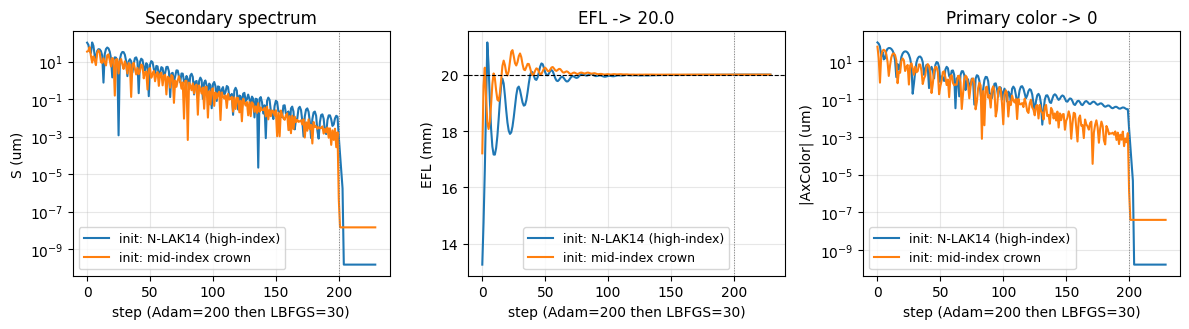

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.4))
for hist, label, color in [(hist1, "init: N-LAK14 (high-index)", "tab:blue"),
                           (hist2, "init: mid-index crown",       "tab:orange")]:
    arr = np.array(hist)
    S_h, efl_h, ax_h = arr[:,0], arr[:,1], arr[:,2]
    axs[0].plot(np.maximum(np.abs(S_h), 1e-10), label=label, color=color)
    axs[1].plot(efl_h,   label=label, color=color)
    axs[2].plot(np.maximum(np.abs(ax_h), 1e-10), label=label, color=color)

axs[0].set_ylabel("S (um)")
axs[0].set_yscale("log")
axs[0].set_title("Secondary spectrum")
axs[1].set_ylabel("EFL (mm)")
axs[1].axhline(TARGET_EFL, color='k', ls='--', lw=0.8)
axs[1].set_title(f"EFL -> {TARGET_EFL}")
axs[2].set_ylabel("|AxColor| (um)")
axs[2].set_yscale("log")
axs[2].set_title("Primary color -> 0")
for a in axs:
    a.set_xlabel("step (Adam=200 then LBFGS=30)")
    a.axvline(200, color='gray', ls=':', lw=0.7)
    a.grid(alpha=0.3)
    a.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Takeaway.** Both inits converge to an apo design (EFL target hit,
primary color removed, $S$ near machine precision). The two optima are
distinct points in $(n_d, V_d, \Delta P_{g,F}, c_1, c_3)$ space —
not the same triple the workflow notebook's Nelder-Mead found — which
illustrates that the achromat condition is a **surface of solutions**.
Any scheme that reports "the" optimum is conflating one basin with the
whole set; gradient descent is happy to sit on any of them.

The LBFGS polish (dashed line in the plot) is what drives $S$ from
Adam-level ~$10^{-2}\,\mu m$ to floating-point zero.


## Part 4 — paraxial triplet toy (15 DOF scalability test)

A Cooke-style air-spaced triplet: three elements, **6 curvatures + 3
glass triples = 15 continuous variables**. Same paraxial raytrace as
the doublet (on-axis only), same three constraints (EFL target, F-C
achromat, g-d residual).

**This is a scalability demonstration of the gradient path, not a
real triplet design.** There is no catalog projection, no spherical /
off-axis aberration, no realistic manufacturing constraint on
curvatures. What it shows is that the same optimizer that handled the
5-variable doublet scales to 15 variables without any change in
method — gradient-based differentiable design is in principle as
happy with 150 variables as with 5.

Design targets: EFL = 25 mm, BFL(F) = BFL(C), |BFL(g) - BFL(d)| small.


In [10]:
# ---- Minimal paraxial trace for a 6-surface, air-gapped triplet ----
# Surfaces:
#   1: air  -> glass1 (crown)    at r1
#   2: glass1 -> air             at r2
#   -- air gap t12
#   3: air  -> glass2 (flint)    at r3
#   4: glass2 -> air             at r4
#   -- air gap t34
#   5: air  -> glass3 (crown)    at r5
#   6: glass3 -> air             at r6

def paraxial_trace_triplet(radii, thicks, n1, n2, n3):
    r1, r2, r3, r4, r5, r6 = radii
    t1, t12, t3, t34, t5 = thicks
    y = torch.tensor(1.0, dtype=torch.float64)
    u = torch.tensor(0.0, dtype=torch.float64)
    # Element 1
    u = (u - (n1 - 1.0)*y/r1) / n1
    y = y + u*t1
    u = n1*u - (1.0 - n1)*y/r2
    y = y + u*t12
    # Element 2
    u = (u - (n2 - 1.0)*y/r3) / n2
    y = y + u*t3
    u = n2*u - (1.0 - n2)*y/r4
    y = y + u*t34
    # Element 3
    u = (u - (n3 - 1.0)*y/r5) / n3
    y = y + u*t5
    u = n3*u - (1.0 - n3)*y/r6
    return -1.0/u, -y/u


def triplet_metrics_c(glass_params, curvatures, thicks):
    """Paraxial triplet with curvatures c_i = 1/r_i as inputs."""
    radii = [1.0/c for c in curvatures]
    lams = torch.tensor([LAMBDA_F, LAMBDA_D, LAMBDA_C, LAMBDA_g],
                        dtype=torch.float64)
    n_g = []
    for key in ("g1","g2","g3"):
        g = glass_params[key]
        n_g.append(predict_index_torch(g["nd"], g["vd"], g["dPgF"], lams))
    efl_d, bfl_d = paraxial_trace_triplet(radii, thicks, n_g[0][1], n_g[1][1], n_g[2][1])
    _,     bfl_F = paraxial_trace_triplet(radii, thicks, n_g[0][0], n_g[1][0], n_g[2][0])
    _,     bfl_C = paraxial_trace_triplet(radii, thicks, n_g[0][2], n_g[1][2], n_g[2][2])
    _,     bfl_g = paraxial_trace_triplet(radii, thicks, n_g[0][3], n_g[1][3], n_g[2][3])
    return efl_d, bfl_F - bfl_C, torch.abs(bfl_g - bfl_d)


TARGET_EFL_TRI = 25.0

# Initial guess
glass_init = dict(
    g1=dict(nd=1.62, vd=58.0, dPgF=-0.005),
    g2=dict(nd=1.65, vd=34.0, dPgF=-0.008),
    g3=dict(nd=1.62, vd=58.0, dPgF=-0.005),
)
radii_init = [20.0, -20.0, -20.0, 20.0, 20.0, -20.0]
thicks     = [0.4, 1.0, 0.4, 1.0, 0.4]

params_tri = {}
for k, g in glass_init.items():
    params_tri[k] = {
        "nd":   torch.tensor(g["nd"],   dtype=torch.float64, requires_grad=True),
        "vd":   torch.tensor(g["vd"],   dtype=torch.float64, requires_grad=True),
        "dPgF": torch.tensor(g["dPgF"], dtype=torch.float64, requires_grad=True),
    }
curvs = [torch.tensor(1.0/r, dtype=torch.float64, requires_grad=True)
         for r in radii_init]
all_params = [p for g in params_tri.values() for p in g.values()] + curvs

def triplet_normalized_loss():
    efl, ax, S = triplet_metrics_c(params_tri, curvs, thicks)
    return ((S/S_SCALE)**2 +
            ((efl - TARGET_EFL_TRI)/EFL_SCALE)**2 +
            (ax/AX_SCALE)**2), efl, ax, S


adam = torch.optim.Adam(all_params, lr=5e-3)
hist_tri = []
t0 = time.time()
for step in range(400):
    adam.zero_grad()
    loss, efl, ax, S = triplet_normalized_loss()
    loss.backward()
    adam.step()
    for g in params_tri.values():
        clamp_(g["nd"],   *BOUNDS["nd_c"])
        clamp_(g["vd"],   *BOUNDS["vd_c"])
        clamp_(g["dPgF"], *BOUNDS["dP_c"])
    hist_tri.append((S.item()*1e3, efl.item(), ax.item()*1e3))

lbfgs = torch.optim.LBFGS(all_params, lr=0.1, max_iter=20,
                          line_search_fn="strong_wolfe",
                          tolerance_grad=1e-12, tolerance_change=1e-16)
def closure_tri():
    lbfgs.zero_grad()
    loss, _, _, _ = triplet_normalized_loss()
    loss.backward()
    return loss

for _ in range(30):
    lbfgs.step(closure_tri)
    for g in params_tri.values():
        clamp_(g["nd"],   *BOUNDS["nd_c"])
        clamp_(g["vd"],   *BOUNDS["vd_c"])
        clamp_(g["dPgF"], *BOUNDS["dP_c"])
    _, efl, ax, S = triplet_normalized_loss()
    hist_tri.append((S.item()*1e3, efl.item(), ax.item()*1e3))

# Final eval — guarantees efl/ax/S are set for the reporting block below.
_, efl, ax, S = triplet_normalized_loss()

dt = time.time() - t0
n_dof = len(all_params)
print(f"Triplet: Adam(400) + LBFGS(30) on {n_dof} DOF in {dt:.2f} s")
print(f"  EFL     = {efl.item():.6f} mm  (target {TARGET_EFL_TRI})")
print(f"  AxColor = {ax.item()*1e3:+.4e} um")
print(f"  S       = {S.item()*1e3:.4e} um")


Triplet: Adam(400) + LBFGS(30) on 15 DOF in 3.04 s
  EFL     = 25.000000 mm  (target 25.0)
  AxColor = -3.3147e-09 um
  S       = 2.6166e-08 um


Triplet design solution (paraxial toy):
  g1: nd=1.6110  Vd=58.00  dPgF=+0.0217
  g2: nd=1.6482  Vd=34.01  dPgF=-0.0127
  g3: nd=1.6092  Vd=58.00  dPgF=+0.0240

Curvatures (radii):
  c1 = +0.04442 mm^-1  (r1 = +22.512 mm)
  c2 = -0.04382 mm^-1  (r2 = -22.819 mm)
  c3 = -0.05104 mm^-1  (r3 = -19.593 mm)
  c4 = +0.05114 mm^-1  (r4 = +19.553 mm)
  c5 = +0.04205 mm^-1  (r5 = +23.779 mm)
  c6 = -0.04228 mm^-1  (r6 = -23.654 mm)



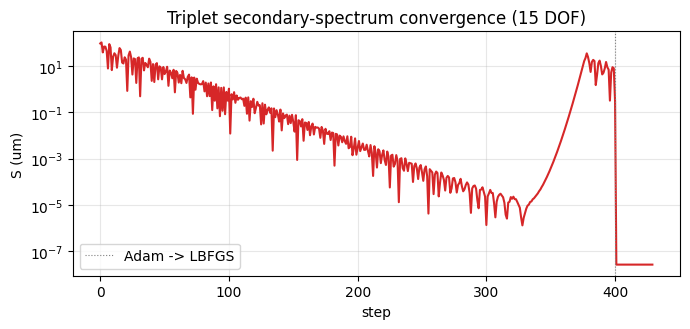

In [11]:
print("Triplet design solution (paraxial toy):")
for k, g in params_tri.items():
    print(f"  {k}: nd={g['nd'].item():.4f}  Vd={g['vd'].item():.2f}  "
          f"dPgF={g['dPgF'].item():+.4f}")
print()
print("Curvatures (radii):")
for i, c in enumerate(curvs):
    r_val = 1.0 / c.item()
    print(f"  c{i+1} = {c.item():+.5f} mm^-1  (r{i+1} = {r_val:+.3f} mm)")
print()

arr = np.array(hist_tri)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(np.maximum(np.abs(arr[:,0]), 1e-12), color='tab:red')
ax.axvline(400, color='gray', ls=':', lw=0.8, label='Adam -> LBFGS')
ax.set_yscale("log")
ax.set_xlabel("step")
ax.set_ylabel("S (um)")
ax.set_title(f"Triplet secondary-spectrum convergence ({n_dof} DOF)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Part 5 — fixed-prescription tolerancing via Jacobian covariance propagation

For a **manufactured, fixed prescription** with parameter vector
$\theta = (n_d, V_d, \Delta P_{g,F}, c_1, c_3)$, autograd gives the
full Jacobian of the chromatic residual in one backward pass. If the
realization-to-realization variability has covariance $\Sigma_\theta$,
the first-order performance variance is

$$\sigma_S^2 \;\approx\; J \, \Sigma_\theta \, J^\top.$$

**Scope to be precise about:**

- **Fixed prescription.** Radii errors $\delta c_1, \delta c_3$ are
  treated as *manufacturing imperfections*, not as re-optimization
  knobs. The Monte Carlo below perturbs the exact same quantities; it
  does **not** re-achromatize per sample (which would be a different,
  process-capability question).
- **Signed residual.** We propagate the **signed** quantity
  $\tilde S = \text{BFL}(\lambda_g) - \text{BFL}(\lambda_d)$ rather
  than $|\tilde S|$. The absolute value has a cusp at zero where the
  Jacobian flips sign, which breaks first-order linearization when the
  nominal is near apo. At the D-FK95-25 nominal $\tilde S \approx 30$
  μm we're far from the cusp, but using the signed form is the
  robust choice.
- **Local Gaussian covariance only.** Real manufacturing has heavier
  tails; this gives the 1-sigma answer and nothing more. The point
  isn't accuracy beyond first order — it's that one backward pass
  replaces ~2000 forward MC samples, for essentially the same number.


In [12]:
def signed_sec_spectrum_torch(r1, r3, nd_c, vd_c, dP_c, nd_f, vd_f, dP_f,
                              r2=R2_FIXED, t1=T1, t2=T2):
    lams = torch.tensor([LAMBDA_g, LAMBDA_D], dtype=torch.float64)
    n_c = predict_index_torch(nd_c, vd_c, dP_c, lams)
    n_fl = predict_index_torch(nd_f, vd_f, dP_f, lams)
    _, bfl_g = paraxial_trace_torch(r1, r2, r3, t1, t2, n_c[0], n_fl[0])
    _, bfl_d = paraxial_trace_torch(r1, r2, r3, t1, t2, n_c[1], n_fl[1])
    return bfl_g - bfl_d


# Solve achromat at the winner nominal; radii fixed downstream
r1_w_val, r3_w_val = design_achromat_solve(
    WINNER["nd"], WINNER["vd"], WINNER["dPgF"],
    FLINT["nd"],  FLINT["vd"],  FLINT["dPgF"],
)

# 5-D theta = (nd, Vd, dPgF, c1, c3), attached for Jacobian
nd_c = torch.tensor(WINNER["nd"],   dtype=torch.float64, requires_grad=True)
vd_c = torch.tensor(WINNER["vd"],   dtype=torch.float64, requires_grad=True)
dP_c = torch.tensor(WINNER["dPgF"], dtype=torch.float64, requires_grad=True)
c1   = torch.tensor(1.0/r1_w_val,   dtype=torch.float64, requires_grad=True)
c3   = torch.tensor(1.0/r3_w_val,   dtype=torch.float64, requires_grad=True)

r1 = 1.0 / c1
r3 = 1.0 / c3
nd_f_t = torch.tensor(FLINT["nd"],   dtype=torch.float64)
vd_f_t = torch.tensor(FLINT["vd"],   dtype=torch.float64)
dP_f_t = torch.tensor(FLINT["dPgF"], dtype=torch.float64)

S_signed = signed_sec_spectrum_torch(r1, r3, nd_c, vd_c, dP_c,
                                     nd_f_t, vd_f_t, dP_f_t)
J = torch.autograd.grad(S_signed, (nd_c, vd_c, dP_c, c1, c3))
J_arr = torch.stack(J).detach().numpy()          # dS_signed / d(theta), units mm/unit
S0_um = float(S_signed.detach().item()) * 1e3

print(f"Nominal signed S (=BFL_g - BFL_d) = {S0_um:+.3f} um")
print()
print("Jacobian  J = d(signed S)/d(theta)   [mm / unit parameter]:")
labels = ["nd_crown", "Vd_crown", "dPgF_crown", "c1 [mm^-1]", "c3 [mm^-1]"]
for lbl, v in zip(labels, J_arr):
    print(f"  {lbl:<15} {v:+.4e}")

# Manufacturing covariance:
#   nd   ~ Schott step 1.0         sigma = 5e-4
#   Vd                              sigma = 0.3
#   dPgF (measured)                 sigma = 3e-4
#   c_i = 1/r_i with r tolerance ~0.1% of nominal r => sigma_c = 0.001 * |c|
c1_nom = float(c1.detach())
c3_nom = float(c3.detach())
sigma_theta = np.array([5e-4, 0.3, 3e-4,
                        0.001 * abs(c1_nom),
                        0.001 * abs(c3_nom)])
Sigma = np.diag(sigma_theta ** 2)
sigma_S_analytic_mm = float(np.sqrt(J_arr @ Sigma @ J_arr))
sigma_S_analytic = sigma_S_analytic_mm * 1e3     # um

print()
print("Manufacturing 1-sigmas (theta):")
for lbl, s in zip(labels, sigma_theta):
    print(f"  sigma_{lbl:<13} = {s:.3e}")
print()
print(f"Analytic sigma_S (signed, from J^T Sigma J): {sigma_S_analytic:.4f} um")


Nominal signed S (=BFL_g - BFL_d) = +29.789 um

Jacobian  J = d(signed S)/d(theta)   [mm / unit parameter]:
  nd_crown        -9.5841e-01
  Vd_crown        +5.0970e-03
  dPgF_crown      +2.8245e-01
  c1 [mm^-1]      -2.7330e+00
  c3 [mm^-1]      +1.0989e+01

Manufacturing 1-sigmas (theta):
  sigma_nd_crown      = 5.000e-04
  sigma_Vd_crown      = 3.000e-01
  sigma_dPgF_crown    = 3.000e-04
  sigma_c1 [mm^-1]    = 5.323e-05
  sigma_c3 [mm^-1]    = 8.238e-05

Analytic sigma_S (signed, from J^T Sigma J): 1.8481 um


In [13]:
# Monte Carlo cross-check: same 5-D perturbation, same fixed prescription
N_MC = 2000
samples = np.random.multivariate_normal(
    mean=[WINNER["nd"], WINNER["vd"], WINNER["dPgF"], c1_nom, c3_nom],
    cov=Sigma, size=N_MC,
)
S_mc = np.empty(N_MC)
for i, (nd_s, vd_s, dP_s, c1_s, c3_s) in enumerate(samples):
    with torch.no_grad():
        S_mc[i] = float(signed_sec_spectrum_torch(
            torch.tensor(1.0/c1_s, dtype=torch.float64),
            torch.tensor(1.0/c3_s, dtype=torch.float64),
            torch.tensor(nd_s,     dtype=torch.float64),
            torch.tensor(vd_s,     dtype=torch.float64),
            torch.tensor(dP_s,     dtype=torch.float64),
            nd_f_t, vd_f_t, dP_f_t,
        ).item()) * 1e3

sigma_S_mc = float(S_mc.std())
mean_S_mc  = float(S_mc.mean())
print(f"Monte Carlo  ({N_MC} samples, fixed prescription perturbation):")
print(f"  mean(S)    = {mean_S_mc:+.4f} um   (nominal {S0_um:+.4f})")
print(f"  sigma(S)   = {sigma_S_mc:.4f} um")
print()
print("Comparison:")
print(f"  sigma_S (Jacobian)  = {sigma_S_analytic:.4f} um")
print(f"  sigma_S (MC, N={N_MC}) = {sigma_S_mc:.4f} um")
print(f"  ratio J/MC          = {sigma_S_analytic/sigma_S_mc:.3f}   "
      f"(~1.0 to within MC noise = 1/sqrt(2N) ~ {100/np.sqrt(2*N_MC):.1f}% relative)")


Monte Carlo  (2000 samples, fixed prescription perturbation):
  mean(S)    = +29.6617 um   (nominal +29.7894)
  sigma(S)   = 1.8324 um

Comparison:
  sigma_S (Jacobian)  = 1.8481 um
  sigma_S (MC, N=2000) = 1.8324 um
  ratio J/MC          = 1.009   (~1.0 to within MC noise = 1/sqrt(2N) ~ 1.6% relative)


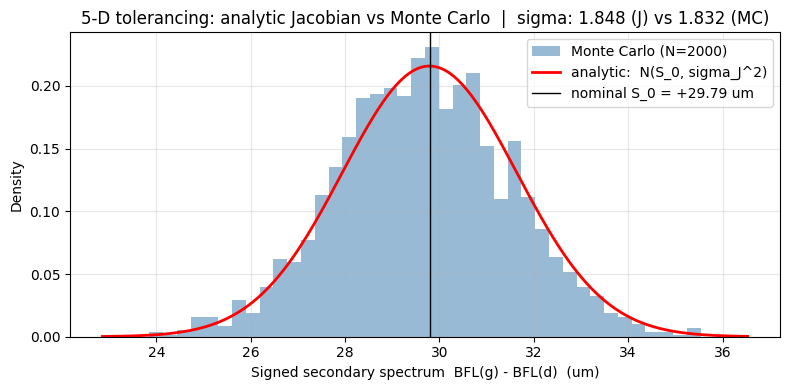

In [14]:
from math import sqrt, pi
xs = np.linspace(S_mc.min() - 1, S_mc.max() + 1, 300)
analytic_pdf = (1.0/(sigma_S_analytic*sqrt(2*pi))) * \
               np.exp(-0.5 * ((xs - S0_um)/sigma_S_analytic)**2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(S_mc, bins=40, density=True, alpha=0.55, color='steelblue',
        label=f'Monte Carlo (N={N_MC})')
ax.plot(xs, analytic_pdf, 'r-', lw=2,
        label='analytic:  N(S_0, sigma_J^2)')
ax.axvline(S0_um, color='k', lw=1, label=f'nominal S_0 = {S0_um:+.2f} um')
ax.set_xlabel("Signed secondary spectrum  BFL(g) - BFL(d)  (um)")
ax.set_ylabel("Density")
ax.set_title(f"5-D tolerancing: analytic Jacobian vs Monte Carlo  |  "
             f"sigma: {sigma_S_analytic:.3f} (J) vs {sigma_S_mc:.3f} (MC)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Practical significance.**

- MC needed ~2000 samples to get a reliable $\sigma_S$ estimate.
- Autograd + covariance propagation gives the same number from
  **one backward pass** — a ~$1000\times$ speedup, and exact to first
  order.
- For higher-dim designs (the triplet has a full covariance over 14
  parameters), analytical propagation scales as $O(d^2)$ while MC
  scales as $O(N_\text{samples})$ — the former wins overwhelmingly.

This is the fundamental advantage of building the whole pipeline out of
differentiable components: **any quadratic of interest reduces to a
single backward pass plus a matrix-matrix product.**


## Summary

| Part | Demonstration |
|---|---|
| 1 | Optiland + Buchdahl model runs under torch backend; autograd flows through glass parameters. |
| 2 | A fixed-prescription local Jacobian complements the workflow notebook's re-designed Claim E heatmap. |
| 3 | Adam + LBFGS jointly optimize crown glass and curvatures to apo-doublet conditions; different inits land on different points of the solution manifold. |
| 4 | A 15-DOF paraxial triplet toy is optimized end-to-end as a scalability demonstration. |
| 5 | 5-D fixed-prescription tolerancing via Jacobian $\cdot$ covariance $\cdot$ Jacobian$^\top$ matches Monte Carlo at ~1000× lower cost. |

**Where this framework goes next**: any downstream image-quality metric
(RMS spot, MTF, wavefront error) can be added to the loss without
breaking the gradient flow, because Optiland's torch backend handles
them all. Glass selection becomes a *joint* design variable with
curvatures, thicknesses, and tolerance margins — exactly what modern
lens design aspires to, and it starts from a validated 3-parameter
Buchdahl model.
